# 02 · Benchmark: TabPFN-3.5 vs XGBoost

Reads only `results/02_benchmark/` (written by `experiments/02_*.py`); no models are fitted and
no API is called here. Every number is printed from those files. RMSE over repeated splits is
sqrt(mean of per-split MSEs), as in Hamidieh (2018).

In [1]:
import glob
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

B = Path("../results/02_benchmark")
FIG = B / "figures"
table = pd.read_csv(B / "metrics.csv")
paired = pd.DataFrame(json.loads((B / "paired.json").read_text()))
ORDER = ["tabpfn", "xgb_tuned", "xgb_hamidieh", "nn_lookup", "linear"]
KINDS = ["random", "grouped", "grouped_no_oxygen"]


def pivot(df, value, digits=2):
    p = df.pivot_table(index=["model", "features"], columns="kind", values=value)
    p = p.reindex(sorted(p.index, key=lambda i: (ORDER.index(i[0]), i[1])))
    return p[[k for k in KINDS if k in p.columns]].round(digits)

## 1. Replication of the paper on the random split
Published-settings XGBoost and linear regression next to the numbers in Hamidieh (2018).

In [2]:
pd.DataFrame(json.loads((B / "replication.json").read_text())).T

,paper,composition,engineered
linear,"{'rmse': 17.6, 'r2': 0.74}","{'rmse': 19.35173946295243, 'r2': 0.6804881953...","{'rmse': 17.619365380507716, 'r2': 0.735134543..."
nn_lookup,None,"{'rmse': 11.196153688349723, 'r2': 0.893051404...",NaN
tabpfn,None,"{'rmse': 8.704081180142275, 'r2': 0.9353644057...","{'rmse': 8.715867429437845, 'r2': 0.9351907124..."
xgb_hamidieh,"{'rmse': 9.5, 'r2': 0.92}","{'rmse': 9.646449696815395, 'r2': 0.9206093782...","{'rmse': 9.424193201755303, 'r2': 0.9242272949..."
xgb_tuned,None,"{'rmse': 9.55425474082474, 'r2': 0.92212106897...","{'rmse': 9.344875666967729, 'r2': 0.9254943644..."


## 2. All models, all repeated splits (25 splits each)

In [3]:
allrows = table[(table.group == "all") & table.kind.isin(KINDS)]
display(pivot(allrows, "rmse"))
display(pivot(allrows, "mae"))
pivot(allrows, "r2", 3)

kind                      random  grouped  grouped_no_oxygen
model        features                                       
tabpfn       composition    8.70     8.97               9.95
             engineered     8.72     9.01              10.54
xgb_tuned    composition    9.55     9.90              10.88
             engineered     9.34     9.73              11.04
xgb_hamidieh composition    9.65    10.04              10.85
             engineered     9.42     9.76              10.85
nn_lookup    composition   11.20    11.80              12.82
linear       composition   19.35    19.54              19.82
             engineered    17.62    17.75              18.01

kind                      random  grouped  grouped_no_oxygen
model        features                                       
tabpfn       composition    4.72     4.96               5.42
             engineered     4.65     4.93               5.59
xgb_tuned    composition    5.52     5.79               6.40
             engineered     5.27     5.62               6.34
xgb_hamidieh composition    5.75     6.12               6.59
             engineered     5.25     5.59               6.15
nn_lookup    composition    5.71     6.26               6.83
linear       composition   14.15    14.24              14.47
             engineered    13.36    13.47              13.71

kind                      random  grouped  grouped_no_oxygen
model        features                                       
tabpfn       composition   0.935    0.931              0.917
             engineered    0.935    0.931              0.907
xgb_tuned    composition   0.922    0.916              0.900
             engineered    0.926    0.919              0.898
xgb_hamidieh composition   0.921    0.914              0.901
             engineered    0.924    0.919              0.901
nn_lookup    composition   0.893    0.881              0.861
linear       composition   0.680    0.674              0.669
             engineered    0.735    0.731              0.727

## 3. TabPFN vs XGBoost, split by split
Same splits, seeds and features for both models. `mean_diff` < 0 means TabPFN has lower RMSE.

In [4]:
paired[paired.b.isin(["xgb_tuned", "xgb_hamidieh"])][
    ["kind", "features", "b", "mean_diff", "std_diff", "a_better_splits", "n_splits"]
].round(3)

,kind,features,b,mean_diff,std_diff,a_better_splits,n_splits
2,grouped,composition,xgb_hamidieh,-1.071,0.095,25,25
3,grouped,composition,xgb_tuned,-0.929,0.154,25,25
6,grouped,engineered,xgb_hamidieh,-0.746,0.142,25,25
7,grouped,engineered,xgb_tuned,-0.716,0.149,25,25
10,grouped_no_oxygen,composition,xgb_hamidieh,-0.908,0.249,25,25
11,grouped_no_oxygen,composition,xgb_tuned,-0.944,0.329,25,25
14,grouped_no_oxygen,engineered,xgb_hamidieh,-0.344,0.434,18,25
15,grouped_no_oxygen,engineered,xgb_tuned,-0.526,0.681,19,25
18,random,composition,xgb_hamidieh,-0.943,0.094,25,25
19,random,composition,xgb_tuned,-0.849,0.156,25,25


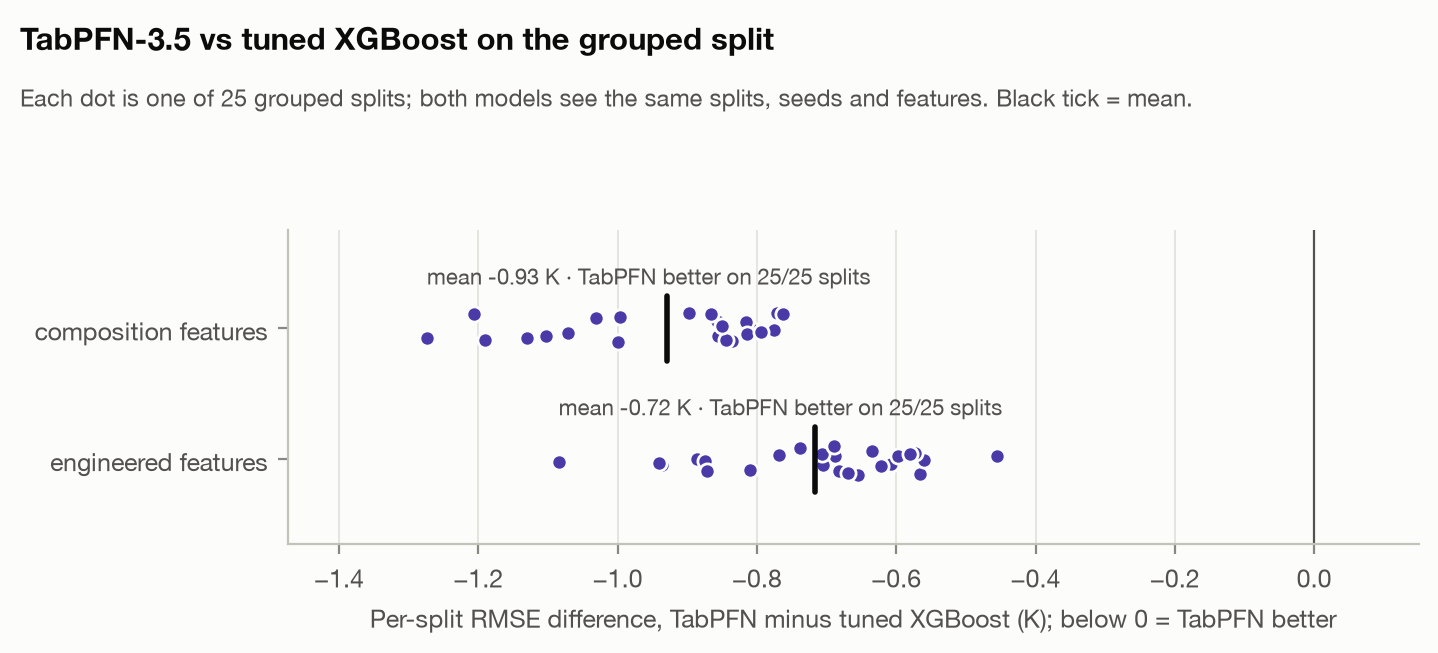

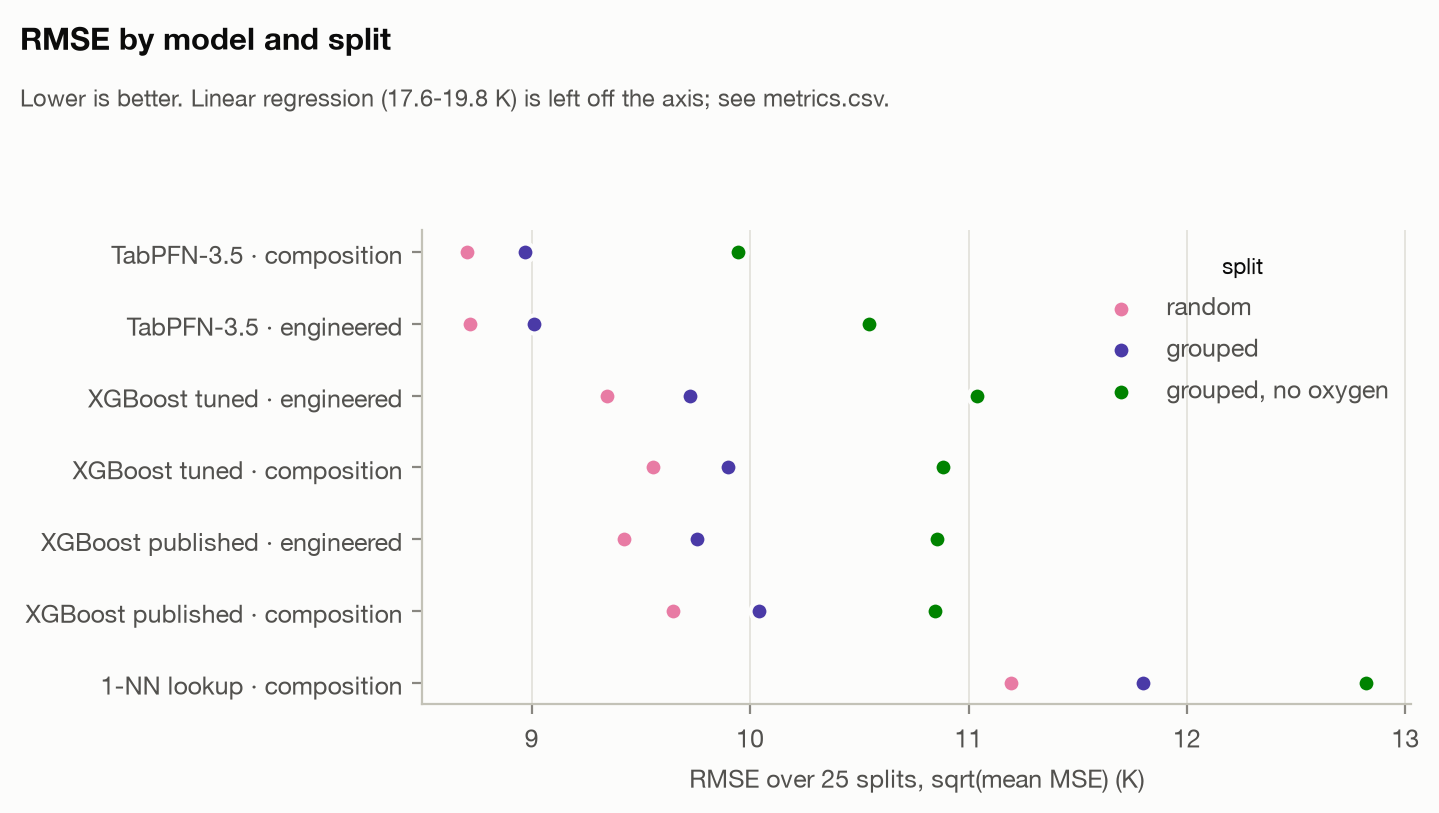

In [5]:
display(Image(FIG / "paired_difference_grouped.png"))
display(Image(FIG / "rmse_by_split_kind.png"))

## 4. Grouped split by Tc band, family, and missing-oxygen rows
Rows whose formula gives no oxygen amount are encoded as O = 1 (see the Phase 1 audit); they are
kept, as in the paper, and reported separately.

In [6]:
g = table[(table.kind == "grouped") & table.model.isin(["tabpfn", "xgb_tuned", "xgb_hamidieh"])]
g.pivot_table(index="group", columns=["model", "features"], values="rmse").round(2)

model                      tabpfn            xgb_hamidieh             \
features              composition engineered  composition engineered   
group                                                                  
10-77 K                     10.47      10.44        11.18      11.00   
Tc < 10 K                    4.53       4.37         5.70       5.20   
Tc > 77 K                   11.27      11.62        13.28      12.89   
all                          8.97       9.01        10.04       9.76   
family: cuprate             11.71      11.85        13.09      12.72   
family: iron-based           7.18       6.71         7.85       7.46   
family: other                4.43       4.30         5.07       4.95   
oxygen amount missing       12.90      12.80        14.29      14.10   

model                   xgb_tuned             
features              composition engineered  
group                                         
10-77 K                     11.35      11.08  
Tc < 10 K                    5.17       5.02  
Tc > 77 K                   12.76      12.74  
all                          9.90       9.73  
family: cuprate             12.96      12.72  
family: iron-based           7.89       7.52  
family: other                4.77       4.79  
oxygen amount missing       14.35      14.12

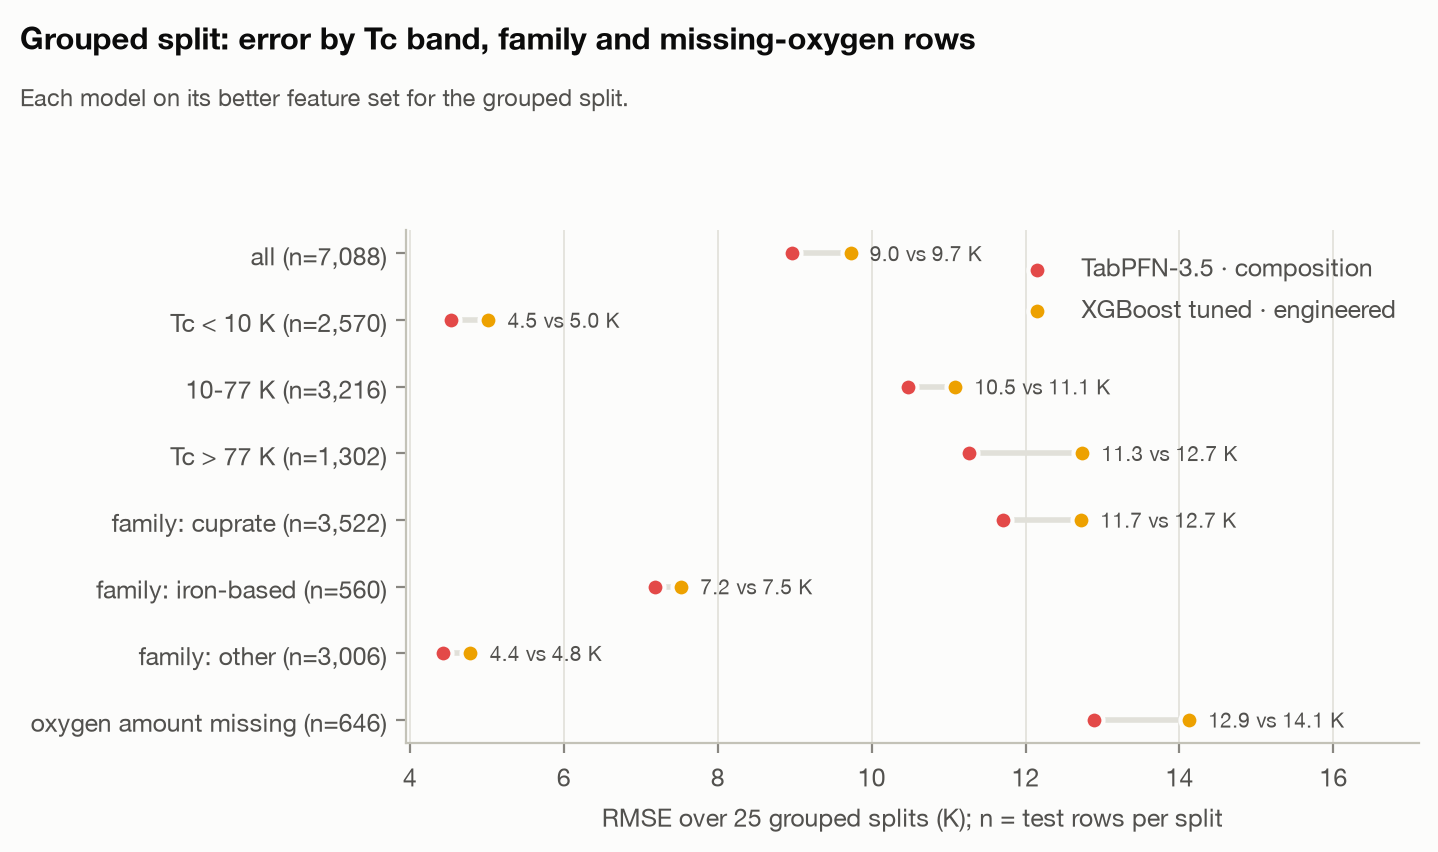

kind                      random  grouped  grouped_no_oxygen
model        features                                       
tabpfn       composition   13.00    12.90              13.05
             engineered    12.89    12.80              12.91
xgb_tuned    composition   14.26    14.35              14.66
             engineered    14.16    14.12              14.47
xgb_hamidieh composition   14.22    14.29              14.42
             engineered    14.22    14.10              14.21
nn_lookup    composition   16.77    17.04              17.04
linear       composition   22.74    22.66              22.92
             engineered    23.09    22.91              23.28

In [7]:
display(Image(FIG / "grouped_subgroups.png"))
m = table[(table.group == "oxygen amount missing") & table.kind.isin(KINDS)]
pivot(m, "rmse")

## 5. Leave-family-out
Each fold trains on two families and tests on the third. Whether TabPFN's intervals widen on the
held-out family is a Phase 3 question.

In [8]:
lfo = table[(table.kind == "leave_family_out") & (table.group == "all")]
display(lfo.pivot_table(index=["model", "features"], columns="fold", values="rmse").round(1))
lfo.pivot_table(index=["model", "features"], columns="fold", values="r2").round(2)

fold                      cuprate  iron-based  other
model        features                               
linear       composition     58.5        25.5  327.4
             engineered      53.5        18.3   56.2
nn_lookup    composition     50.9        22.4   46.7
tabpfn       composition     50.2        20.0   30.9
             engineered      49.0        21.5   20.0
xgb_hamidieh composition     53.7        18.6   22.6
             engineered      46.0        20.6   32.8
xgb_tuned    composition     53.1        21.3   20.4
             engineered      49.5        21.6   25.8

fold                      cuprate  iron-based    other
model        features                                 
linear       composition    -2.52       -3.09 -1499.67
             engineered     -1.95       -1.11   -43.25
nn_lookup    composition    -1.67       -2.17   -29.55
tabpfn       composition    -1.59       -1.51   -12.38
             engineered     -1.47       -1.90    -4.62
xgb_hamidieh composition    -1.97       -1.19    -6.14
             engineered     -1.18       -1.67   -14.03
xgb_tuned    composition    -1.90       -1.86    -4.81
             engineered     -1.53       -1.95    -8.32

## 6. Compute: nested XGBoost tuning vs TabPFN requests
Tuning time is the sum of per-split search times in the tuning records (refits excluded), on one
10-core laptop. TabPFN time is the server-side fit and predict time in each request record; the
whole run's wall-clock (4 requests in flight) is in NOTES.md.

In [9]:
tuning = [
    json.loads(Path(f).read_text()) for f in glob.glob(str(B / "xgb_tuning/*/*/split_*.json"))
]
requests = [json.loads(Path(f).read_text()) for f in glob.glob(str(B / "tabpfn/*/*/split_*.json"))]


def server_seconds(r):
    fit, pred = r["timings"].get("fit") or {}, r["timings"].get("predict") or {}
    keys = (
        "test_set_transform_queue_wait_s",
        "test_set_transform_s",
        "predict_queue_wait_s",
        "predict_s",
    )
    return (fit.get("elapsed_s") or 0) + sum(pred.get(k) or 0 for k in keys)


pd.Series(
    {
        "tuning jobs": len(tuning),
        "tuning search hours": sum(t["seconds"] for t in tuning) / 3600,
        "TabPFN requests": len(requests),
        "TabPFN server-side hours": sum(map(server_seconds, requests)) / 3600,
    }
).round(2)

tuning jobs                 156.00
tuning search hours           2.82
TabPFN requests             156.00
TabPFN server-side hours      0.33
dtype: float64